In [1]:
import sys
print(sys.executable)

/Users/hemantkushwaha/Home-Credit/model/venv/bin/python


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/application_train.csv')
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
print(df['TARGET'].value_counts())
print()
print(df['TARGET'].value_counts(normalize=True) * 100)

TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [4]:
print(df['DAYS_EMPLOYED'].describe())
print()
print((df['DAYS_EMPLOYED'] == 365243).sum(), "rows have the placeholder value 365243")

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

55374 rows have the placeholder value 365243


In [5]:
# Replace the placeholder with NaN (missing) instead of 365243 
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# Check overall missing data
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].head(20)

,missing_count,missing_pct
COMMONAREA_AVG,214865,69.9
COMMONAREA_MODE,214865,69.9
COMMONAREA_MEDI,214865,69.9
NONLIVINGAPARTMENTS_AVG,213514,69.4
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4


In [6]:
# Dropping columns missing more than 40% of their data
threshold = 40
cols_to_drop = missing_summary[missing_summary['missing_pct'] > threshold].index.tolist()

print(f"Dropping {len(cols_to_drop)} columns with >{threshold}% missing data")
print(cols_to_drop)

df_clean = df.drop(columns=cols_to_drop)
print()
print("New shape:", df_clean.shape)

Dropping 49 columns with >40% missing data
['COMMONAREA_AVG', 'COMMONAREA_MODE', 'COMMONAREA_MEDI', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI', 'YEARS_BUILD_AVG', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE', 'OWN_CAR_AGE', 'LANDAREA_MEDI', 'LANDAREA_AVG', 'LANDAREA_MODE', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_MODE', 'EXT_SOURCE_1', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MODE', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'ELEVATORS_AVG', 'WALLSMATERIAL_MODE', 'APARTMENTS_MEDI', 'APARTMENTS_MODE', 'APARTMENTS_AVG', 'ENTRANCES_AVG', 'ENTRANCES_MODE', 'ENTRANCES_MEDI', 'LIVINGAREA_MEDI', 'LIVINGAREA_AVG', 'LIVINGAREA_MODE', 'HOUSETYPE_MODE', 'FLOORSMAX_AVG', 'FLOORSMAX_MEDI', 'FLOORSMAX_MODE', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_MO

In [7]:
print(df['EXT_SOURCE_1'].isnull().sum(), "missing out of", len(df))
print((df['EXT_SOURCE_1'].isnull().sum() / len(df) * 100).round(1), "% missing")

173378 missing out of 307511
56.4 % missing


In [8]:
# Add EXT_SOURCE_1 back in
df_clean['EXT_SOURCE_1'] = df['EXT_SOURCE_1']

# Create a flag column BEFORE filling, so we don't lose the "was missing" signal
df_clean['EXT_SOURCE_1_MISSING'] = df_clean['EXT_SOURCE_1'].isnull().astype(int)

# Now fill the missing values with the median
median_value = df_clean['EXT_SOURCE_1'].median()
df_clean['EXT_SOURCE_1'] = df_clean['EXT_SOURCE_1'].fillna(median_value)

print("EXT_SOURCE_1 missing after fill:", df_clean['EXT_SOURCE_1'].isnull().sum())
print("New shape:", df_clean.shape)


EXT_SOURCE_1 missing after fill: 0
New shape: (307511, 75)


In [9]:
missing_remaining = df_clean.isnull().sum().sort_values(ascending=False)
missing_remaining_pct = (missing_remaining / len(df_clean) * 100).round(1)
missing_remaining_summary = pd.DataFrame({'missing_count': missing_remaining, 'missing_pct': missing_remaining_pct})
missing_remaining_summary[missing_remaining_summary['missing_count'] > 0]

,missing_count,missing_pct
OCCUPATION_TYPE,96391,31.3
EXT_SOURCE_3,60965,19.8
DAYS_EMPLOYED,55374,18.0
AMT_REQ_CREDIT_BUREAU_YEAR,41519,13.5
AMT_REQ_CREDIT_BUREAU_QRT,41519,13.5
AMT_REQ_CREDIT_BUREAU_MON,41519,13.5
AMT_REQ_CREDIT_BUREAU_WEEK,41519,13.5
AMT_REQ_CREDIT_BUREAU_DAY,41519,13.5
AMT_REQ_CREDIT_BUREAU_HOUR,41519,13.5
NAME_TYPE_SUITE,1292,0.4


In [10]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
categorical_cols = df_clean.select_dtypes(include=['str']).columns

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna("Unknown")

print("Total missing values remaining:", df_clean.isnull().sum().sum())
print("Shape:", df_clean.shape)

Total missing values remaining: 0
Shape: (307511, 75)


In [11]:
categorical_cols = df_clean.select_dtypes(include=['str']).columns
print("Number of categorical columns:", len(categorical_cols))
print()
for col in categorical_cols:
    print(col, "->", df_clean[col].nunique(), "unique values")

Number of categorical columns: 12

NAME_CONTRACT_TYPE -> 2 unique values
CODE_GENDER -> 3 unique values
FLAG_OWN_CAR -> 2 unique values
FLAG_OWN_REALTY -> 2 unique values
NAME_TYPE_SUITE -> 8 unique values
NAME_INCOME_TYPE -> 8 unique values
NAME_EDUCATION_TYPE -> 5 unique values
NAME_FAMILY_STATUS -> 6 unique values
NAME_HOUSING_TYPE -> 6 unique values
OCCUPATION_TYPE -> 19 unique values
WEEKDAY_APPR_PROCESS_START -> 7 unique values
ORGANIZATION_TYPE -> 58 unique values


In [12]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df_clean.select_dtypes(include=['object']).columns
print("Categorical columns found:", list(categorical_cols))

low_cardinality_cols = [col for col in categorical_cols if df_clean[col].nunique() <= 10]
high_cardinality_cols = [col for col in categorical_cols if df_clean[col].nunique() > 10]

print("One-hot encoding these:", low_cardinality_cols)
print("Label encoding these:", high_cardinality_cols)

df_clean = pd.get_dummies(df_clean, columns=low_cardinality_cols, drop_first=True)

le = LabelEncoder()
for col in high_cardinality_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("Final shape after encoding:", df_clean.shape)
print("Any object columns left?", df_clean.select_dtypes(include=['object']).columns.tolist())

/var/folders/86/dzjt3f5j2974f_ls5crb36d40000gn/T/ipykernel_63188/2091331512.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=['object']).columns


Categorical columns found: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']
One-hot encoding these: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START']
Label encoding these: ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
Final shape after encoding: (307511, 104)
Any object columns left? []


In [13]:
from sklearn.model_selection import train_test_split

X=df_clean.drop(columns=['TARGET','SK_ID_CURR'])
y=df_clean['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()
print("Train TARGET distribution:")
print(y_train.value_counts(normalize=True))
print()
print("Test TARGET distribution:")
print(y_test.value_counts(normalize=True))


Train shape: (246008, 102)
Test shape: (61503, 102)

Train TARGET distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Test TARGET distribution:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

#Scaling it down with (value-mean)/sd as the key factor

scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


In [15]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Make predictions on the test set (data the model has NEVER seen)
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Classification report: precision, recall, f1 for both classes
print("Classification Report:")
print(classification_report(y_test, y_pred))

# AUC score
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc:.4f}")

# Confusion matrix - shows exactly what the model got right/wrong
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503

AUC Score: 0.7482

Confusion Matrix:
[[38917 17621]
 [ 1593  3372]]


In [16]:
from xgboost import XGBClassifier

# scale_pos_weight tells XGBoost how much more to weigh the rare class (defaults)
# roughly = (number of non-defaults) / (number of defaults)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc'
)

xgb_model.fit(X_train, y_train)
print("XGBoost trained successfully")

scale_pos_weight: 11.38710976837865
XGBoost trained successfully


In [17]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"XGBoost AUC Score: {auc_xgb:.4f}")

print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.72      0.82     56538
           1       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.71      0.78     61503

XGBoost AUC Score: 0.7596

XGBoost Confusion Matrix:
[[40550 15988]
 [ 1655  3310]]


In [18]:
bureau = pd.read_csv('../data/bureau.csv')
print("Bureau shape:", bureau.shape)
bureau.head()

Bureau shape: (1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [19]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU': 'count',           # how many past/active loans with other lenders
    'CREDIT_ACTIVE': lambda x: (x == 'Active').sum(),  # how many are still active
    'AMT_CREDIT_SUM': 'sum',            # total credit amount across all their other loans
    'AMT_CREDIT_SUM_DEBT': 'sum',       # total debt currently owed elsewhere
    'CREDIT_DAY_OVERDUE': 'max',        # worst overdue days on any loan
    'DAYS_CREDIT': 'min',               # how long ago their oldest bureau record is
}).reset_index()

bureau_agg.columns = ['SK_ID_CURR', 'BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_COUNT', 
                       'BUREAU_TOTAL_CREDIT', 'BUREAU_TOTAL_DEBT', 
                       'BUREAU_MAX_OVERDUE', 'BUREAU_OLDEST_CREDIT_DAYS']

print("Aggregated bureau shape:", bureau_agg.shape)
bureau_agg.head()

Aggregated bureau shape: (305811, 7)


,SK_ID_CURR,BUREAU_LOAN_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_TOTAL_CREDIT,BUREAU_TOTAL_DEBT,BUREAU_MAX_OVERDUE,BUREAU_OLDEST_CREDIT_DAYS
0,100001,7,3,1453365.000,596686.5,0,-1572
1,100002,8,2,865055.565,245781.0,0,-1437
2,100003,4,1,1017400.500,0.0,0,-2586
3,100004,2,0,189037.800,0.0,0,-1326
4,100005,3,2,657126.000,568408.5,0,-373


In [20]:
df_clean = df_clean.merge(bureau_agg, on='SK_ID_CURR', how='left')
print("New shape after merging bureau features:", df_clean.shape)

# Applicants with no bureau history at all will have NaN in these new columns - fill with 0
bureau_feature_cols = ['BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_COUNT', 'BUREAU_TOTAL_CREDIT',
                        'BUREAU_TOTAL_DEBT', 'BUREAU_MAX_OVERDUE', 'BUREAU_OLDEST_CREDIT_DAYS']
df_clean[bureau_feature_cols] = df_clean[bureau_feature_cols].fillna(0)

print("Missing values in new bureau columns:", df_clean[bureau_feature_cols].isnull().sum().sum())

New shape after merging bureau features: (307511, 110)
Missing values in new bureau columns: 0


In [21]:
prev_app = pd.read_csv('../data/previous_application.csv')
print("Previous applications shape:", prev_app.shape)
prev_app.head()

Previous applications shape: (1670214, 37)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
prev_agg = prev_app.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'count',                                          # how many times they've applied before
    'NAME_CONTRACT_STATUS': lambda x: (x == 'Approved').sum(),      # how many were approved
    'AMT_CREDIT': 'mean',                                           # average credit amount they've asked for
    'AMT_ANNUITY': 'mean',                                          # average annuity on past applications
    'DAYS_DECISION': 'max',                                         # most recent application (closest to 0 = most recent)
}).reset_index()

prev_agg.columns = ['SK_ID_CURR', 'PREV_APP_COUNT', 'PREV_APPROVED_COUNT',
                     'PREV_AVG_CREDIT', 'PREV_AVG_ANNUITY', 'PREV_MOST_RECENT_DECISION']

print("Aggregated previous_application shape:", prev_agg.shape)
prev_agg.head()

Aggregated previous_application shape: (338857, 6)


,SK_ID_CURR,PREV_APP_COUNT,PREV_APPROVED_COUNT,PREV_AVG_CREDIT,PREV_AVG_ANNUITY,PREV_MOST_RECENT_DECISION
0,100001,1,1,23787.00,3951.000,-1740
1,100002,1,1,179055.00,9251.775,-606
2,100003,3,3,484191.00,56553.990,-746
3,100004,1,1,20106.00,5357.250,-815
4,100005,2,1,20076.75,4813.200,-315


In [23]:
df_clean = df_clean.merge(prev_agg, on='SK_ID_CURR', how='left')
print("New shape after merging previous_application features:", df_clean.shape)

prev_feature_cols = ['PREV_APP_COUNT', 'PREV_APPROVED_COUNT', 'PREV_AVG_CREDIT',
                      'PREV_AVG_ANNUITY', 'PREV_MOST_RECENT_DECISION']
df_clean[prev_feature_cols] = df_clean[prev_feature_cols].fillna(0)

print("Missing values in new previous_application columns:", df_clean[prev_feature_cols].isnull().sum().sum())

New shape after merging previous_application features: (307511, 115)
Missing values in new previous_application columns: 0


In [24]:
installments = pd.read_csv('../data/installments_payments.csv')
print("Installments shape:", installments.shape)
installments.head()

Installments shape: (13605401, 8)


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [25]:
# Create a "days late" column: positive = paid late, negative/zero = paid on time or early
installments['DAYS_LATE'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
installments['AMT_SHORTFALL'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']

install_agg = installments.groupby('SK_ID_CURR').agg({
    'DAYS_LATE': 'mean',            # average how many days late they typically pay
    'AMT_SHORTFALL': 'mean',        # average how much less than owed they typically paid
    'SK_ID_PREV': 'count',          # total number of installments across all their loans
}).reset_index()

install_agg.columns = ['SK_ID_CURR', 'INSTALL_AVG_DAYS_LATE', 'INSTALL_AVG_SHORTFALL', 'INSTALL_COUNT']

print("Aggregated installments shape:", install_agg.shape)
install_agg.head()

Aggregated installments shape: (339587, 4)


,SK_ID_CURR,INSTALL_AVG_DAYS_LATE,INSTALL_AVG_SHORTFALL,INSTALL_COUNT
0,100001,-7.285714,0.0,7
1,100002,-20.421053,0.0,19
2,100003,-7.160000,0.0,25
3,100004,-7.666667,0.0,3
4,100005,-23.555556,0.0,9


In [26]:
df_clean = df_clean.merge(install_agg, on='SK_ID_CURR', how='left')
print("New shape after merging installments features:", df_clean.shape)

install_feature_cols = ['INSTALL_AVG_DAYS_LATE', 'INSTALL_AVG_SHORTFALL', 'INSTALL_COUNT']
df_clean[install_feature_cols] = df_clean[install_feature_cols].fillna(0)

print("Missing values in new installments columns:", df_clean[install_feature_cols].isnull().sum().sum())

New shape after merging installments features: (307511, 118)
Missing values in new installments columns: 0


In [27]:
pos_cash = pd.read_csv('../data/POS_CASH_balance.csv')
print("POS_CASH shape:", pos_cash.shape)

pos_agg = pos_cash.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'nunique',           # how many distinct past POS/cash loans
    'SK_DPD': 'max',                   # worst "days past due" ever recorded
    'CNT_INSTALMENT_FUTURE': 'mean',   # average installments remaining (loan progress indicator)
}).reset_index()

pos_agg.columns = ['SK_ID_CURR', 'POS_LOAN_COUNT', 'POS_MAX_DPD', 'POS_AVG_INSTALMENTS_LEFT']

df_clean = df_clean.merge(pos_agg, on='SK_ID_CURR', how='left')
pos_feature_cols = ['POS_LOAN_COUNT', 'POS_MAX_DPD', 'POS_AVG_INSTALMENTS_LEFT']
df_clean[pos_feature_cols] = df_clean[pos_feature_cols].fillna(0)

print("New shape after merging POS_CASH features:", df_clean.shape)
print("Missing values:", df_clean[pos_feature_cols].isnull().sum().sum())

POS_CASH shape: (10001358, 8)
New shape after merging POS_CASH features: (307511, 121)
Missing values: 0


In [28]:
credit_card = pd.read_csv('../data/credit_card_balance.csv')
print("Credit card shape:", credit_card.shape)

cc_agg = credit_card.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'nunique',                # how many distinct credit cards
    'AMT_BALANCE': 'mean',                  # average balance carried
    'AMT_CREDIT_LIMIT_ACTUAL': 'mean',      # average credit limit
    'SK_DPD': 'max',                        # worst days past due on any card
}).reset_index()

cc_agg.columns = ['SK_ID_CURR', 'CC_COUNT', 'CC_AVG_BALANCE', 'CC_AVG_LIMIT', 'CC_MAX_DPD']

df_clean = df_clean.merge(cc_agg, on='SK_ID_CURR', how='left')
cc_feature_cols = ['CC_COUNT', 'CC_AVG_BALANCE', 'CC_AVG_LIMIT', 'CC_MAX_DPD']
df_clean[cc_feature_cols] = df_clean[cc_feature_cols].fillna(0)

print("New shape after merging credit_card features:", df_clean.shape)
print("Missing values:", df_clean[cc_feature_cols].isnull().sum().sum())

Credit card shape: (3840312, 23)
New shape after merging credit_card features: (307511, 125)
Missing values: 0


In [29]:
X = df_clean.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df_clean['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (246008, 123)
Test shape: (61503, 123)


In [30]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc'
)

xgb_model_v2.fit(X_train, y_train)
print("XGBoost v2 (with engineered features) trained successfully")

XGBoost v2 (with engineered features) trained successfully


In [31]:
y_pred_v2 = xgb_model_v2.predict(X_test)
y_pred_proba_v2 = xgb_model_v2.predict_proba(X_test)[:, 1]

print("XGBoost v2 Classification Report:")
print(classification_report(y_test, y_pred_v2))

auc_v2 = roc_auc_score(y_test, y_pred_proba_v2)
print(f"XGBoost v2 AUC Score: {auc_v2:.4f}")
print(f"Previous XGBoost AUC (application data only): 0.7596")
print(f"Improvement: {auc_v2 - 0.7596:.4f}")

print("\nXGBoost v2 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_v2))

XGBoost v2 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.74      0.83     56538
           1       0.18      0.67      0.29      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.71      0.56     61503
weighted avg       0.90      0.73      0.79     61503

XGBoost v2 AUC Score: 0.7765
Previous XGBoost AUC (application data only): 0.7596
Improvement: 0.0169

XGBoost v2 Confusion Matrix:
[[41680 14858]
 [ 1621  3344]]


In [32]:
import shap

# Create an explainer for our XGBoost model
explainer = shap.TreeExplainer(xgb_model_v2)

# Calculate SHAP values for a sample of the test set (full test set can be slow)
sample_size = 1000
X_test_sample = X_test.sample(sample_size, random_state=42)

shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated for", sample_size, "applicants")
print("Shape:", shap_values.shape)

SHAP values calculated for 1000 applicants
Shape: (1000, 123)


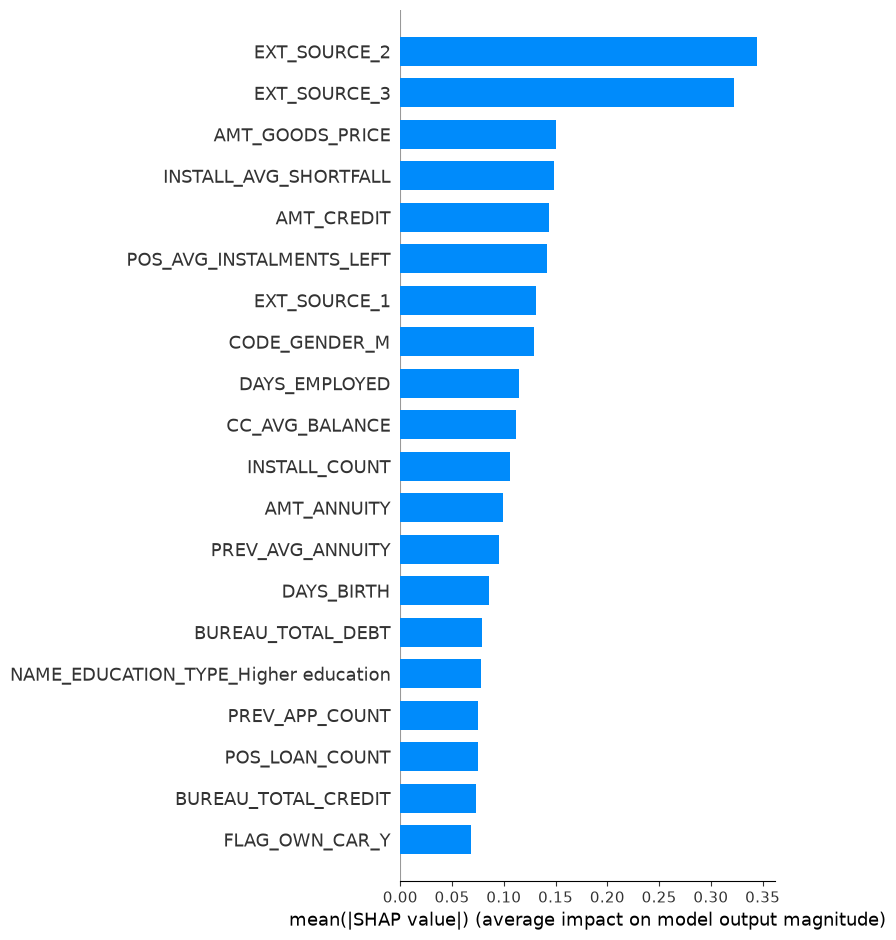

In [33]:
shap.summary_plot(shap_values, X_test_sample, plot_type='bar', show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig('../saved_models/shap_feature_importance.png', dpi=100)
plt.show()

Applicant's predicted risk: 0.9062325



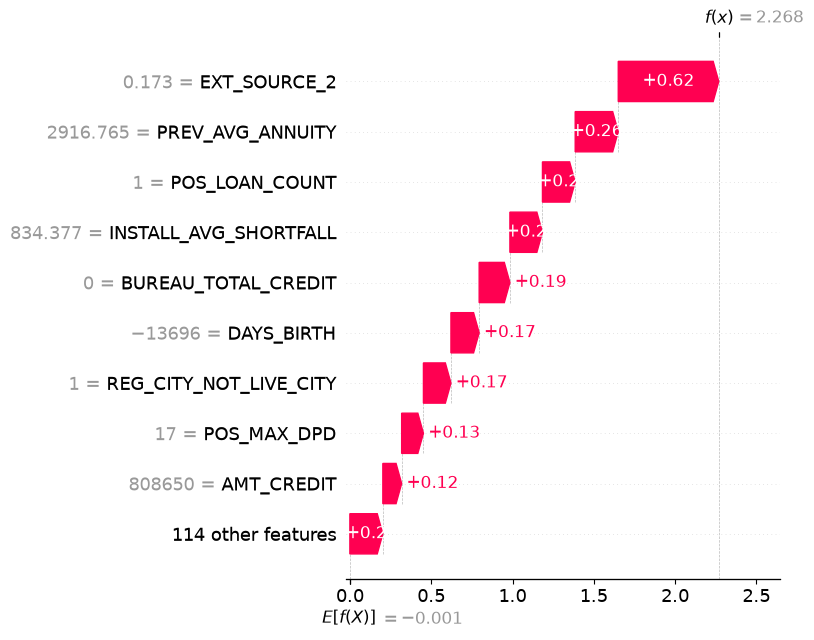

In [34]:
# Pick one applicant from our sample - let's find one with a high predicted risk
sample_predictions = xgb_model_v2.predict_proba(X_test_sample)[:, 1]
high_risk_idx = sample_predictions.argmax()  # find the applicant with the highest predicted risk

print("Applicant's predicted risk:", sample_predictions[high_risk_idx])
print()

# Show their individual SHAP breakdown
shap.waterfall_plot(shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test_sample.iloc[high_risk_idx],
    feature_names=X_test_sample.columns.tolist()
), max_display=10, show=False)

import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig('../saved_models/shap_individual_example.png', dpi=100, bbox_inches='tight')
plt.show()

In [35]:
import joblib

joblib.dump(xgb_model_v2, '../saved_models/credit_risk_model.pkl')
joblib.dump(X.columns.tolist(), '../saved_models/model_features.pkl')

print("Model saved successfully")

Model saved successfully


In [36]:
import os
print(os.getcwd())

/Users/hemantkushwaha/Home-Credit/model/notebooks


In [37]:
import os
print(os.path.exists('../saved_models/credit_risk_model.pkl'))
print(os.path.exists('../saved_models/model_features.pkl'))
print()
print("Contents of saved_models folder:")
print(os.listdir('../saved_models'))

True
True

Contents of saved_models folder:
['credit_risk_model.pkl', 'shap_individual_example.png', 'model_features.pkl', 'shap_feature_importance.png']


In [38]:
# Save the median value of every feature, from the training data
feature_medians = X_train.median().to_dict()

import joblib
joblib.dump(feature_medians, '../saved_models/feature_medians.pkl')

print("Saved medians for", len(feature_medians), "features")

Saved medians for 123 features
